In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Plot for LSTM SHORT

In [5]:
# default styles for plots:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

file_path = '../outputs/lstm_predictions_mw_short.csv'

df_preds = pd.read_csv(file_path)
display(df_preds.head())

,actual_mw_step1,predicted_mw_step1
0,56848.92,54898.305
1,58169.77,56696.395
2,59389.38,58270.490
3,60438.76,59801.145
4,61782.72,60981.586


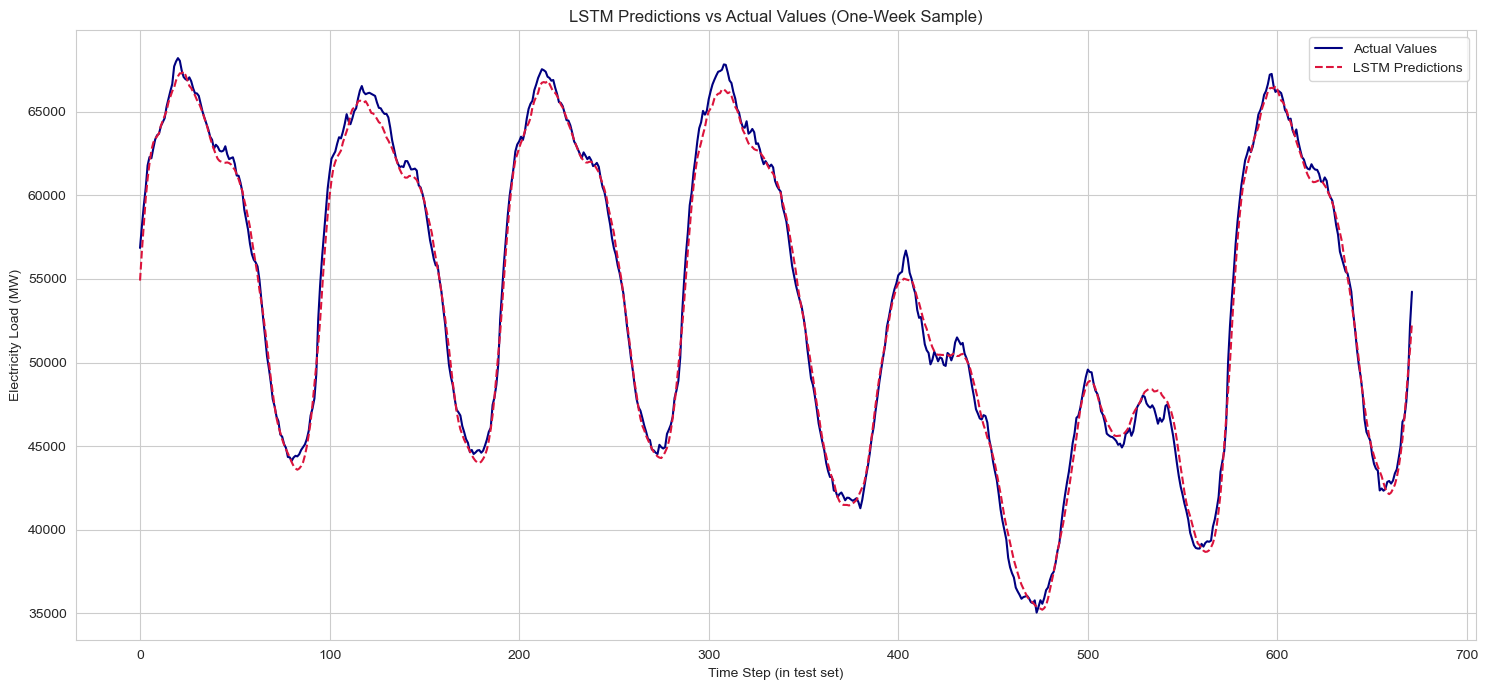

In [ ]:
start_index = 0
end_index = 672 # 7 days * 96 steps/day

plt.figure()
plt.plot(df_preds.index[start_index:end_index], df_preds['actual_mw_step1'][start_index:end_index], label='Actual Values', color='navy')
plt.plot(df_preds.index[start_index:end_index], df_preds['predicted_mw_step1'][start_index:end_index], label='LSTM Predictions', color='crimson', linestyle = '--')

plt.title('LSTM Predictions vs Actual Values (One-Week Sample)')
plt.xlabel('Time Step (in test set)')
plt.ylabel('Electricity Load (MW)')
plt.legend()
plt.tight_layout()

plt.show()

Forecast horizon vs. Visualization window:
1. Forecast Horizon - @ any single point in time, model looks at the past and predicts next 24 hours
2. Visualization Window - test contains results of model performing 'next day prediction' over and over. Therefore plotting just 1 week of this, as a representative slice. Therefore start to end index 672 accounts for 7 days.

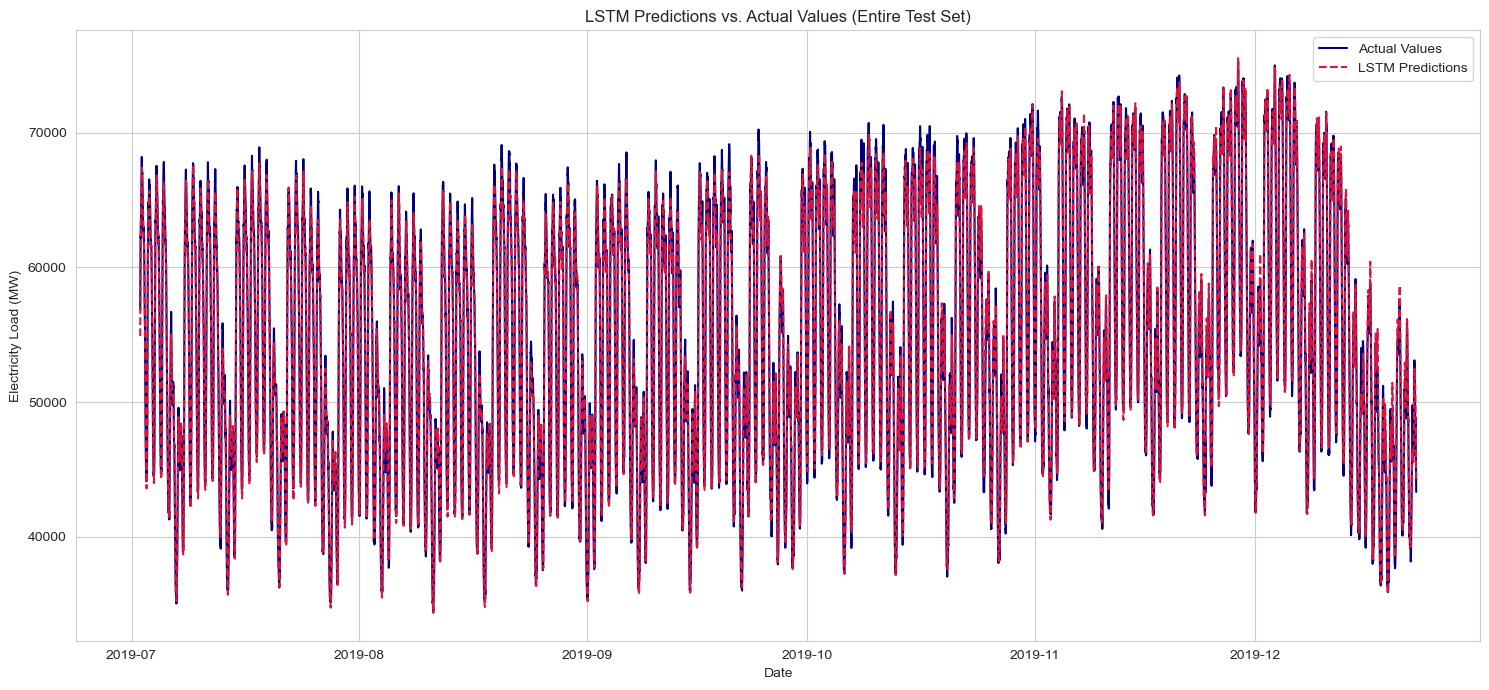

In [13]:
test_start_date = '2019-07-02 04:30:00+00:00'
datetime_index = pd.to_datetime(pd.date_range(start=test_start_date,
                                             periods = len(df_preds),
                                             freq = '15min'))
df_preds.set_index(datetime_index, inplace=True)

plt.figure()

plt.plot(df_preds.index, df_preds['actual_mw_step1'], label='Actual Values', color='navy')
plt.plot(df_preds.index, df_preds['predicted_mw_step1'], label='LSTM Predictions', color='crimson', linestyle='--')

plt.title('LSTM Predictions vs. Actual Values (Entire Test Set)')
plt.xlabel('Date') # The x-axis label is now 'Date'
plt.ylabel('Electricity Load (MW)')
plt.legend()
plt.tight_layout()

plt.show()

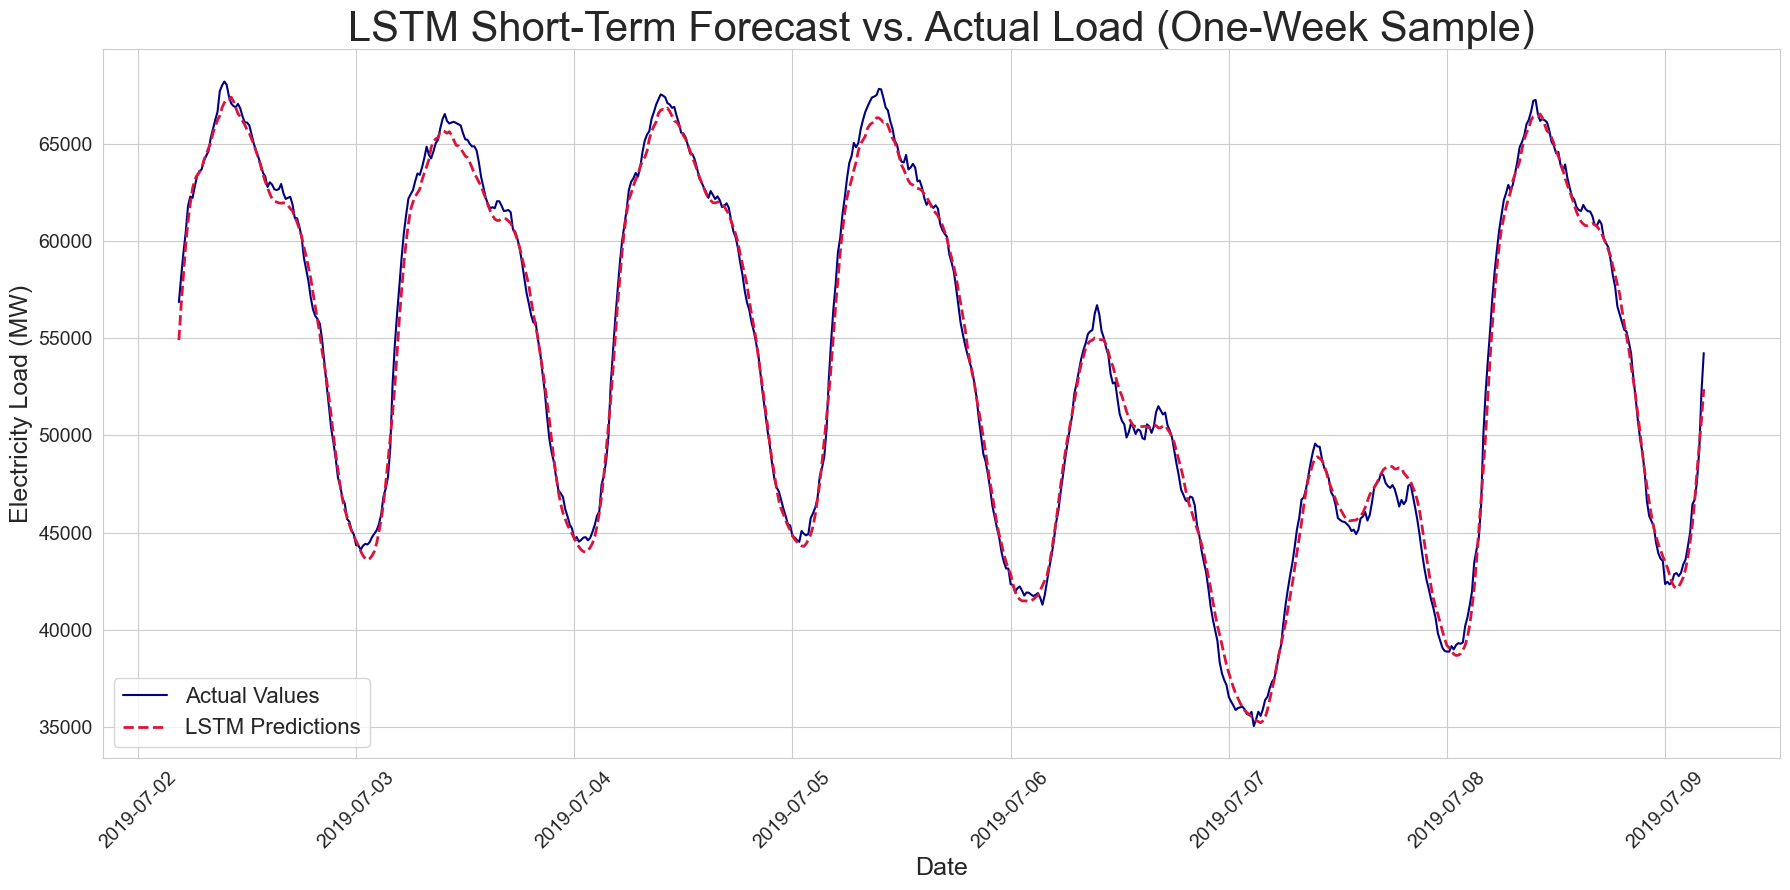

In [17]:
start_index = 0
end_index = 672

df_plot_window = df_preds.iloc[start_index:end_index]

plt.figure(figsize=(18, 9))

plt.plot(df_plot_window.index, df_plot_window['actual_mw_step1'], label='Actual Values', color='navy')
plt.plot(df_plot_window.index, df_plot_window['predicted_mw_step1'], label='LSTM Predictions', color='crimson', linestyle='--', linewidth = 2)

plt.title('LSTM Short-Term Forecast vs. Actual Load (One-Week Sample)', fontsize=30)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Electricity Load (MW)', fontsize=18)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize = 16, frameon = True, loc = 'best')
plt.tight_layout()

# plt.savefig('lstm_short_term_forecast.png', dpi=300, bbox_inches='tight')

plt.show()

In [18]:
def plot_forecast_vs_actuals(df, model_name, horizon, start_step = 0, days_to_plot = 7):
    # window to plot
    end_step = start_step + (days_to_plot * 96)  # 96 steps per day
    df_plot_window = df.iloc[start_step:end_step]

    plt.plot(df_plot_window.index, df_plot_window['actual_mw_step1'], label='Actual Values', color='navy')
    plt.plot(df_plot_window.index, df_plot_window['predicted_mw_step1'], label=f'{model_name} Predictions', color='crimson', linestyle='--', linewidth=2)

    title_text = f'{model_name} {horizon} Forecast vs. Actual Load ({days_to_plot}-Day Sample)'
    plt.title(title_text, fontsize=30)
    plt.xlabel('Date', fontsize=18)
    plt.ylabel('Electricity Load (MW)', fontsize=18)
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=16, frameon=True, loc='best')
    plt.tight_layout()

    plt.show()

# Scatter Plot for LSTM SHORT

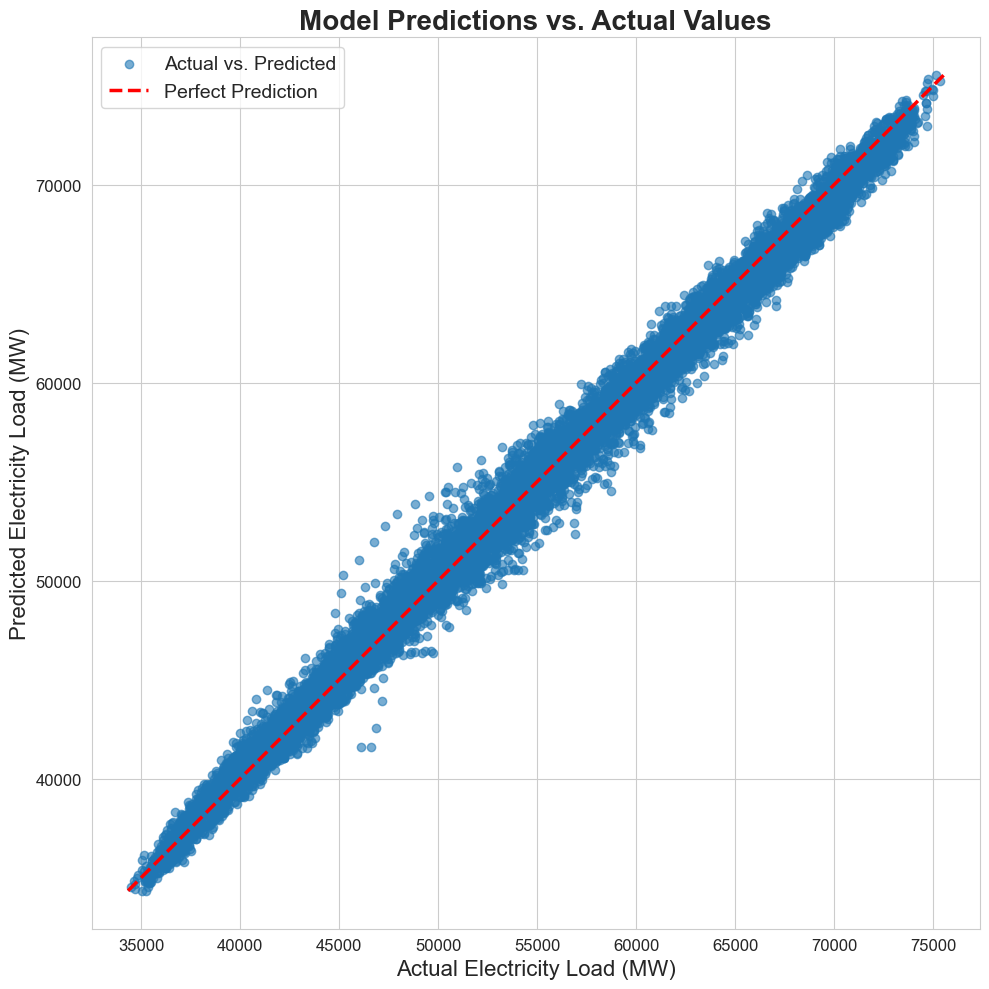

In [19]:
plt.figure(figsize=(10, 10))

plt.scatter(x = df_preds['actual_mw_step1'],
            y = df_preds['predicted_mw_step1'],
            alpha = 0.6,
            label = 'Actual vs. Predicted')

min_val = df_preds.min().min()
max_val = df_preds.max().max()
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--',
         linewidth = 2.5,
         label='Perfect Prediction')

plt.title('Model Predictions vs. Actual Values', fontsize=20, fontweight='bold')
plt.xlabel('Actual Electricity Load (MW)', fontsize=16)
plt.ylabel('Predicted Electricity Load (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14, frameon=True, loc='best')

plt.axis('equal')
plt.grid(True)
plt.tight_layout()

plt.show()

First impressions:
1. High accuracy and correlation (closely aligned with perfect prediction line). Strong (+) correlation between model's predictions and actual values.
2. No obvious systemic bias. Cluster of points is centered on the red line across the entire range. Model doesn't have a siple, naive bias. Errors balanced around zero.
3. Subtle under-prediction at extremem peaks. Right top corner, above 70000MW, slight tendency for blue dots to fall just below red line. Model struggles a bit to predict the absolute highest peaks in demand.
4. Slightly Higher Error at Extremes: cloud of points gets thicker at the bottom left. Model's prediction errors are a bit larger when the load is unusually low or unusually high. Most confident during normal conditions

IS 4 really the case?

# Residuals Plot for LSTM SHORT


Summary Statistics of Residuals:
count    16683.000000
mean        47.188432
std        871.444406
min      -5466.484000
25%       -507.926000
50%         54.400000
75%        597.721500
max       5018.058000
Name: residuals, dtype: float64


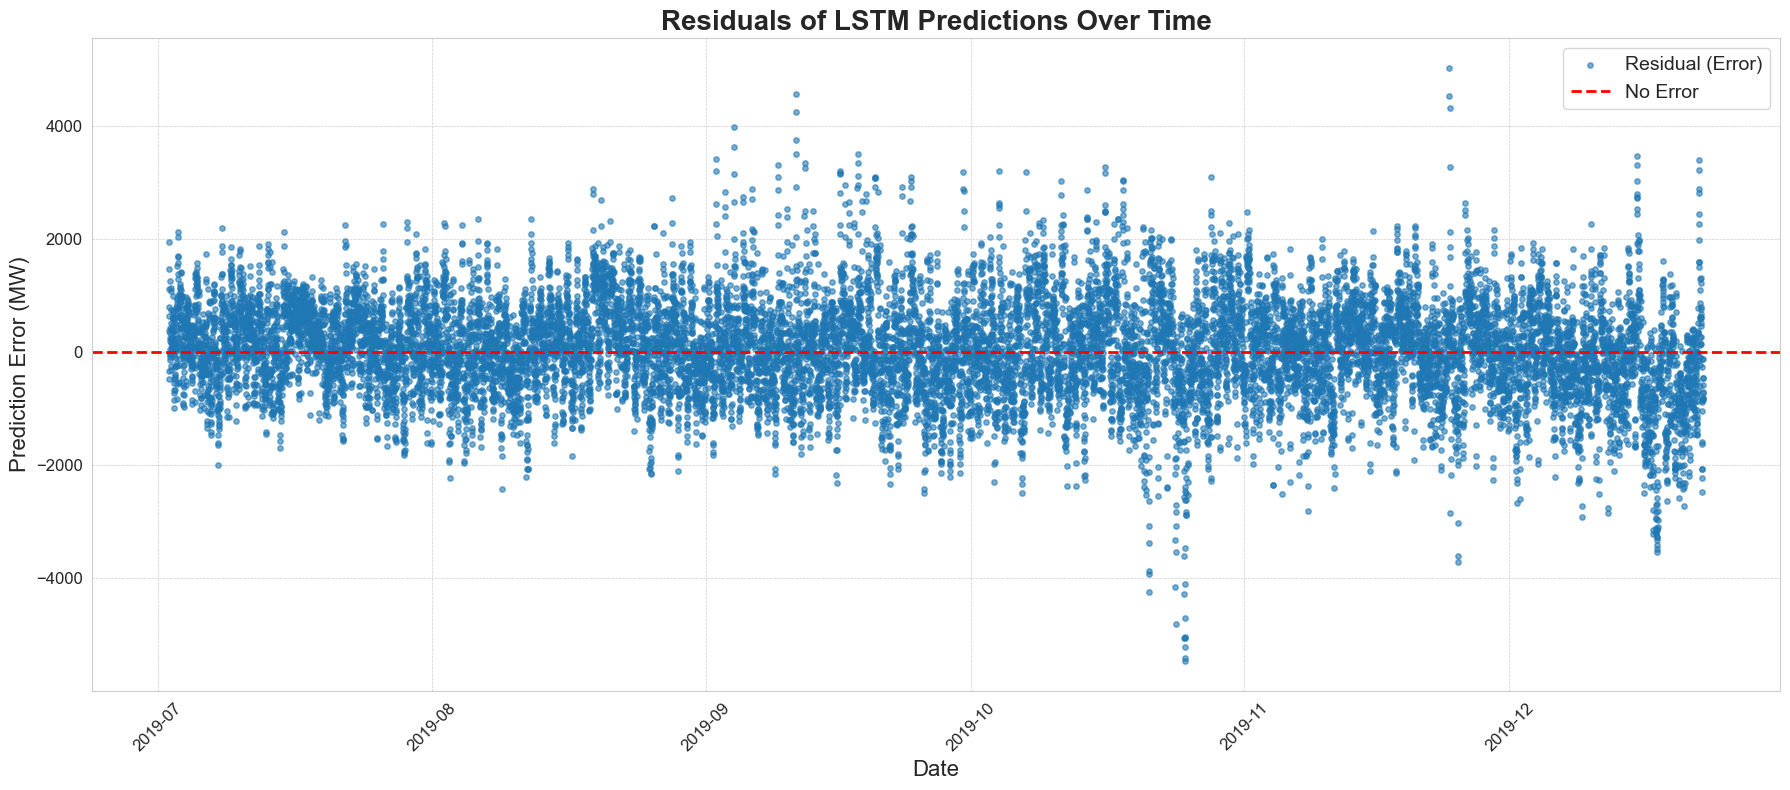

In [22]:
df_preds['residuals'] = df_preds['actual_mw_step1'] - df_preds['predicted_mw_step1']

plt.figure(figsize=(18, 8))

plt.scatter(df_preds.index, df_preds['residuals'],
            alpha = 0.6,
            s = 15,
            label = 'Residual (Error)')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='No Error')

plt.title('Residuals of LSTM Predictions Over Time', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Prediction Error (MW)', fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

print("\nSummary Statistics of Residuals:")
print(df_preds['residuals'].describe())

Analysis:
1. Errors are Centered on Zero: dense cloud of dots centered nicely on the red. Confirmed by mean from statistics. Model is unbiased!
2. No obvious waves/patterns. Errors are random or static. No repeating, wave like shapes. Model has successfully learned the major time-dependent patterns (daily/weekly cycles), rest is noise
3. Spread of errors != constant (heteroscedasticity). Vertical spread of the points change over time
- Periods where blue dots are tightly packed (2019-09 and end of 2019-10)
- Model's accuracy is not uniform over time. More confident during certain periods, less during others (still sensitive to volatility)